## Importing necessary libraries

In [1]:
import flowermd
import gsd
import gsd.hoomd
import hoomd
import matplotlib.pyplot as plt
import mbuild as mb
import numpy as np
import warnings
from cmeutils.visualize import FresnelGSD
from flowermd.base import Pack, Simulation, System, Molecule
from flowermd.base.forcefield import BaseHOOMDForcefield
from flowermd.library import KremerGrestBeadSpring, LJChain
from flowermd.library.forcefields import BeadSpring
from flowermd.utils import get_target_box_number_density
from mbuild.compound import Compound
from mbuild.lattice import Lattice
import unyt as u
warnings.filterwarnings('ignore')

/Users/joselyngutierrez/miniconda3/envs/mxene/lib/python3.12/site-packages/gmso/core/element.py:10: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_filename


## Switch to .CPU() if running on CPU, GPU if on GPU

In [2]:
cpu = hoomd.device.CPU()

## Class defining flake geometry

In [3]:
class Graphene(System):
    def __init__(
        self,
        x_repeat,
        y_repeat,
        n_layers,
        base_units=dict(),
        periodicity=(True, True, False),
    ):
        surface = mb.Compound(periodicity=periodicity)
        a = 3**.5
        lattice = Lattice(
            lattice_spacing=[a,a,a],
            lattice_vectors=  [[a,0,0],[a/2,3/2,0],[0,0,1]],
            lattice_points={"A": [[1/3,1/3,0], [2/3, 2/3, 0]]},
        ) 
        Flakium = Compound(name="F", element="F") # defines a carbon atom that will be used to populate lattice points
        layers = lattice.populate(
            compound_dict={"A": Flakium}, x=x_repeat, y=y_repeat, z=n_layers
        ) # populates the lattice using the previously defined carbon atom for every "A" site, repeated in all x,y, and z directions
        surface.add(layers) # adds populated carbon lattice layers to the 'surface' compound, which represents our graphene structure 
        surface.freud_generate_bonds("F", "F", dmin=0.9, dmax=1.1) # generates bonds depending on input distance range, scales with lattice
        surface_mol = Molecule(num_mols=1, compound=surface) # wraps into a Molecule object, creating "1" instance of this molecule

        super(Graphene, self).__init__(
            molecules=[surface_mol],
            base_units=base_units,
        )

    def _build_system(self):
        return self.all_molecules[0]
#OK, so we want to initialize a system with some chains and some flakes

## Forcefield parameters defining WCA interactions, essentially zero attraction, pure repulsion

In [4]:
ff = BeadSpring(
    r_cut=2**(1/6),  
    beads={
        "A": dict(epsilon=1.0, sigma=1.0),  # chains
        "F": dict(epsilon=1.0, sigma=1.0),  # flakes
    },
    bonds={
        "F-F": dict(r0=1.0, k=1000),
        "A-A": dict(r0=1.0, k=1000.0),  # increased k to avoid chain collapse
    },
    angles={
        "A-A-A": dict(t0=2* np.pi / 3., k=100.0),   # moderate stiffness for chains
        "F-F-F": dict(t0=2 * np.pi / 3., k=5000),
    },
    dihedrals={
        "A-A-A-A": dict(phi0=0.0, k=0, d=-1, n=2), #need to turn this on later, messed up with straight chains
        "F-F-F-F": dict(phi0=0.0, k=500, d=-1, n=2),
    }
)

## Simulation parameters

In [81]:
N_chains = 5
initial_dens = 0.001
final_dens = 0.3
N_flakes = 5
chain_length = 10
dt = 0.0005
temp = 3

## Initializing chains, flakes, and system parameters (like initial density -> final density)

In [82]:
kg_chain = LJChain(lengths=chain_length,num_mols=N_chains)
sheet = Graphene(x_repeat=5, y_repeat=5, n_layers=1, periodicity=(False, False, False))
system = Pack(molecules=[Molecule(compound=sheet.all_molecules[0], num_mols=N_flakes), kg_chain], 
              density=initial_dens, packing_expand_factor = 6, seed=2)
target_box = get_target_box_number_density(density=final_dens*u.Unit("nm**-3"),n_beads=(500+(N_chains*10)))

## Output files

In [83]:
gsd = f"{N_chains}_{chain_length}mer{N_flakes}f_{dt}dt.gsd"
log = f"{N_chains}_{chain_length}mer{N_flakes}f_{dt}dt.txt"

## Initializing simulation, shrinking, running, then flushing data into output files.

In [84]:
sim = Simulation(initial_state=system.hoomd_snapshot, forcefield=ff.hoomd_forces, device=cpu, dt = dt, gsd_write_freq=int(100000), log_write_freq=int(1000), log_file_name = log, gsd_file_name = gsd)
#sim.run_update_volume(final_box_lengths=[(1500/0.8)**1/3, (1500/0.8)**1/3, (1500/0.8)**1/3], kT=6.0, n_steps=5e6,tau_kt=100*sim.dt,period=10,thermalize_particles=True)
sim.run_update_volume(final_box_lengths=target_box, kT=6.0, n_steps=5e6,tau_kt=100*sim.dt,period=10,thermalize_particles=True)
sim.run_NVT(n_steps=10e6, kT=temp, tau_kt=dt*100)
sim.flush_writers()

*Warning*: dihedral.harmonic: specified K <= 0


Initializing simulation state from a gsd.hoomd.Frame.
Step 50500 of 5000000; TPS: 17144.23; ETA: 4.8 minutes
Step 101000 of 5000000; TPS: 17802.74; ETA: 4.6 minutes
Step 151500 of 5000000; TPS: 17832.23; ETA: 4.5 minutes
Step 202000 of 5000000; TPS: 17712.45; ETA: 4.5 minutes
Step 252500 of 5000000; TPS: 17825.7; ETA: 4.4 minutes
Step 303000 of 5000000; TPS: 17827.22; ETA: 4.4 minutes
Step 353500 of 5000000; TPS: 17864.56; ETA: 4.3 minutes
Step 404000 of 5000000; TPS: 17936.49; ETA: 4.3 minutes
Step 454500 of 5000000; TPS: 17971.52; ETA: 4.2 minutes
Step 505000 of 5000000; TPS: 17916.09; ETA: 4.2 minutes
Step 555500 of 5000000; TPS: 17940.64; ETA: 4.1 minutes
Step 606000 of 5000000; TPS: 17963.83; ETA: 4.1 minutes
Step 656500 of 5000000; TPS: 17938.38; ETA: 4.0 minutes
Step 707000 of 5000000; TPS: 17942.71; ETA: 4.0 minutes
Step 757500 of 5000000; TPS: 17956.22; ETA: 3.9 minutes
Step 808000 of 5000000; TPS: 17938.47; ETA: 3.9 minutes
Step 858500 of 5000000; TPS: 17939.5; ETA: 3.8 minut

## Visualization of final frame. Can adjust to whatever frame if you'd like

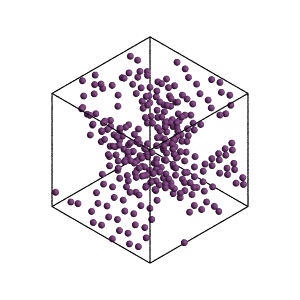

In [85]:
sim_visualizer = FresnelGSD(gsd_file=gsd, frame=-1, view_axis=(1, 1, 1))
sim_visualizer.view()